# 🏗️ Activity 1 — The Transfer Learning Shortcut
**Computer Vision Bootcamp — Day 2 | Saudi Digital Academy × atomcamp Arabia**

---

### 🎯 What you will build today
A **hardhat compliance classifier** for NEOM construction sites — a real Vision 2030 safety application.

The model will look at a construction site photo and answer one question:
> **"Is the worker wearing a hardhat? — Yes or No?"**

You will use **Transfer Learning** with MobileNetV2 — a model already trained on 14 million images — so you only need ~200 images and ~5 minutes of training.

---

### 📋 Parts
| Part | Task | Time |
|------|------|------|
| Part 1 | Load & Explore the Dataset | 8 min |
| Part 2 | Build the Model | 10 min |
| Part 3 | Train & Watch | 10 min |
| Part 4 | Reflect | 7 min |
| ⭐ Bonus | Experiment with epochs | if time |

**How to work:** Run each cell in order. Read the output. Answer questions in the text cells marked ✏️

## ⚙️ Setup — Run this first
This cell installs libraries and generates the dataset. **Run it once and wait for it to finish.**

In [1]:
# ── Setup cell — run once ──────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os, random
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# ── Generate synthetic hardhat dataset ────────────────────────────────
np.random.seed(42)
random.seed(42)

IMG_SIZE = 96   # smaller = faster on Colab CPU
N_TRAIN  = 160  # 80 per class
N_VAL    = 40   # 20 per class

def make_image(has_hardhat, noise_level=0.12):
    """Generate a synthetic construction site image."""
    img = np.ones((IMG_SIZE, IMG_SIZE, 3), dtype=np.float32) * 0.55  # grey background
    # Sky
    img[:IMG_SIZE//3, :] = [0.5, 0.65, 0.85]
    # Ground
    img[2*IMG_SIZE//3:, :] = [0.6, 0.5, 0.35]
    # Worker body
    bx, by = IMG_SIZE//2 - 10, IMG_SIZE//3
    img[by:by+35, bx:bx+20] = [0.9, 0.8, 0.6]  # skin/vest
    # Head
    hx, hy = IMG_SIZE//2 - 7, IMG_SIZE//3 - 14
    img[hy:hy+12, hx:hx+14] = [0.9, 0.75, 0.55]
    if has_hardhat:
        # Hardhat = bright yellow shape above head
        img[hy-8:hy+4, hx-3:hx+17] = [1.0, 0.85, 0.0]
    # Noise
    img += np.random.normal(0, noise_level, img.shape).astype(np.float32)
    return np.clip(img, 0, 1)

def make_dataset(n_per_class, noise=0.12):
    X, y = [], []
    for _ in range(n_per_class):
        X.append(make_image(True,  noise + np.random.uniform(-0.05, 0.05)))
        X.append(make_image(False, noise + np.random.uniform(-0.05, 0.05)))
        y += [1, 0]  # 1 = hardhat, 0 = no hardhat
    idx = list(range(len(X))); random.shuffle(idx)
    return np.array(X)[idx], np.array(y)[idx]

X_train, y_train = make_dataset(N_TRAIN // 2)
X_val,   y_val   = make_dataset(N_VAL   // 2, noise=0.18)

CLASS_NAMES = ['No Hardhat ⛔', 'Hardhat ✅']
print('✅ Setup complete!')
print(f'   Training images : {len(X_train)}  ({sum(y_train==1)} with hardhat, {sum(y_train==0)} without)')
print(f'   Validation images: {len(X_val)}  ({sum(y_val==1)} with hardhat, {sum(y_val==0)} without)')
print(f'   Image shape      : {X_train[0].shape}  (H × W × 3 RGB)')

✅ Setup complete!
   Training images : 160  (80 with hardhat, 80 without)
   Validation images: 40  (20 with hardhat, 20 without)
   Image shape      : (96, 96, 3)  (H × W × 3 RGB)


---
## Part 1 — Load & Explore the Dataset
**Goal:** Look at sample images and understand what the model will learn from.

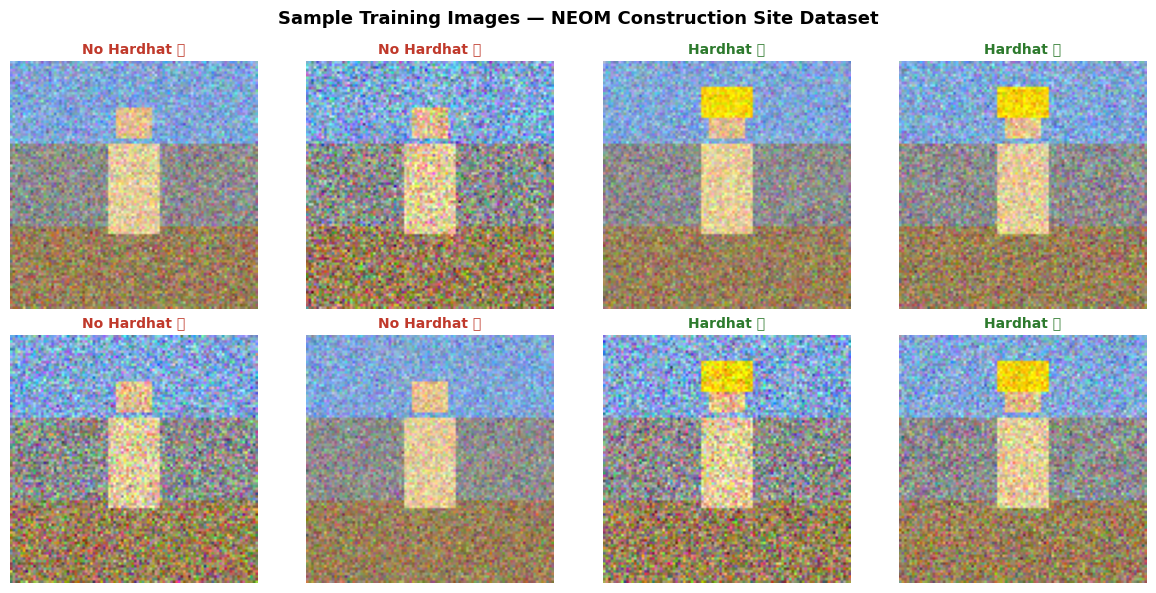

In [2]:
# ── Show 8 sample images ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle('Sample Training Images — NEOM Construction Site Dataset', fontsize=13, fontweight='bold')

shown_hardhat = 0
shown_no_hardhat = 0
indices = []

for i, (x, y) in enumerate(zip(X_train, y_train)):ٍ
    if y == 1 and shown_hardhat < 4:
        indices.append(i); shown_hardhat += 1
    elif y == 0 and shown_no_hardhat < 4:
        indices.append(i); shown_no_hardhat += 1
    if shown_hardhat == 4 and shown_no_hardhat == 4:
        break

for ax, idx in zip(axes.flat, sorted(indices)):
    ax.imshow(X_train[idx])
    label = CLASS_NAMES[y_train[idx]]
    color = '#2d7a2d' if y_train[idx] == 1 else '#c0392b'
    ax.set_title(label, fontsize=10, color=color, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

### ✏️ Questions — answer here

**Q1. Look at the images. How can you tell the difference between "Hardhat" and "No Hardhat"?**

*(Write your answer here — one or two sentences)*

YOUR ANSWER:

The "Hardhat" images have a bright yellow shape above the head, while the "No Hardhat" images show just the bare head.

**Q2. We have 160 training images and 40 validation images. Why do we keep some images separate for validation?**

YOUR ANSWER:

To test the model on new data it hasn't seen before and check if it's overfitting.

---
## Part 2 — Build the Model
**Goal:** Load MobileNetV2 (frozen) and add a new classification head.

> 🔑 **Key idea:** MobileNetV2 already knows how to detect edges, shapes, and textures from 14 million images.
> We keep that knowledge **frozen** (locked), and only train a small new layer on top for our specific task.

In [4]:
# ── Step 1: Load MobileNetV2 backbone (frozen) ─────────────────────────
backbone = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,      # remove the original ImageNet head
    weights='imagenet'      # load pre-trained weights
)
backbone.trainable = False  # 🔒 FREEZE — do not update these weights

print(f'Backbone loaded: {backbone.name}')
print(f'Frozen parameters : {sum(~w.trainable for w in backbone.weights):,}')
print(f'Backbone trainable: {backbone.trainable}')

Backbone loaded: mobilenetv2_1.00_96
Frozen parameters : -260
Backbone trainable: False


In [5]:
# ── Step 2: Add new classification head ───────────────────────────────
model = models.Sequential([
    backbone,
    layers.GlobalAveragePooling2D(),   # flatten feature maps → single vector
    layers.Dense(128, activation='relu'),  # learn hardhat-specific patterns
    layers.Dense(1, activation='sigmoid')  # output: 0.0 (no hardhat) to 1.0 (hardhat)
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Count trainable vs frozen parameters
total      = model.count_params()
trainable  = sum(tf.size(w).numpy() for w in model.trainable_weights)
frozen     = total - trainable

print('\n🏗️  Model Summary')
print(f'   Total parameters    : {total:,}')
print(f'   🔒 Frozen (backbone): {frozen:,}  ← MobileNetV2, not updated')
print(f'   🟢 Trainable (head) : {trainable:,}  ← only these update today')


🏗️  Model Summary
   Total parameters    : 2,422,081
   🔒 Frozen (backbone): 2,257,984  ← MobileNetV2, not updated
   🟢 Trainable (head) : 164,097  ← only these update today


### ✏️ Questions

**Q3. Look at the parameter counts above. How many parameters are frozen vs. trainable?**

YOUR ANSWER:

To test the model on new data it hasn't seen before and check if it's overfitting.

**Q4. In your own words — what does it mean that the backbone is "frozen"?**

*(Hint: what happens to those weights during training?)*

YOUR ANSWER:

It means the weights of MobileNetV2 are locked and won't change during training, so we only train the new head layer.

---
## Part 3 — Train & Watch
**Goal:** Train the model for 5 epochs and observe how accuracy changes.

In [6]:
# ── Train the model ────────────────────────────────────────────────────
print('🚀 Starting training...')
print('   Watch the accuracy column — it should go UP each epoch.\n')

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=16,
    verbose=1
)

final_train_acc = history.history['accuracy'][-1]
final_val_acc   = history.history['val_accuracy'][-1]
print(f'\n✅ Training complete!')
print(f'   Final training accuracy   : {final_train_acc:.1%}')
print(f'   Final validation accuracy : {final_val_acc:.1%}')

🚀 Starting training...
   Watch the accuracy column — it should go UP each epoch.

Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 383ms/step - accuracy: 0.9125 - loss: 0.1843 - val_accuracy: 1.0000 - val_loss: 0.0624
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 148ms/step - accuracy: 1.0000 - loss: 0.0060 - val_accuracy: 0.9500 - val_loss: 0.0883
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - accuracy: 1.0000 - loss: 9.5535e-04 - val_accuracy: 1.0000 - val_loss: 0.0458
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - accuracy: 1.0000 - loss: 6.9506e-04 - val_accuracy: 1.0000 - val_loss: 0.0372
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 1.0000 - loss: 4.7020e-04 - val_accuracy: 1.0000 - val_loss: 0.0497

✅ Training complete!
   Final training accuracy   : 100.0%
   Final validation accuracy : 100.0%


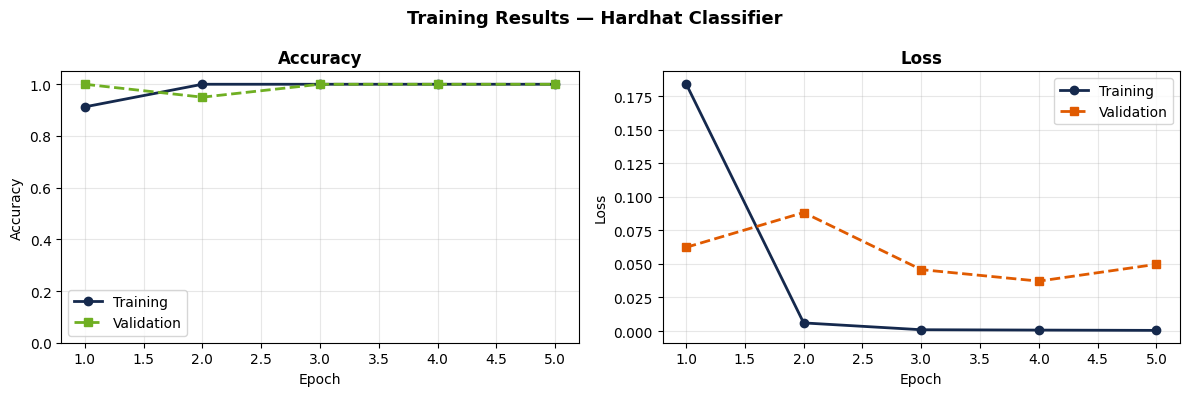

In [7]:
# ── Plot training curves ───────────────────────────────────────────────
epochs = range(1, len(history.history['accuracy']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Training Results — Hardhat Classifier', fontsize=13, fontweight='bold')

# Accuracy
ax1.plot(epochs, history.history['accuracy'],     'o-', color='#15294D', label='Training', linewidth=2)
ax1.plot(epochs, history.history['val_accuracy'], 's--', color='#6FAF22', label='Validation', linewidth=2)
ax1.set_title('Accuracy', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1.05); ax1.legend(); ax1.grid(alpha=0.3)

# Loss
ax2.plot(epochs, history.history['loss'],     'o-', color='#15294D', label='Training', linewidth=2)
ax2.plot(epochs, history.history['val_loss'], 's--', color='#E05A00', label='Validation', linewidth=2)
ax2.set_title('Loss', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### ✏️ Questions — look at the curves above

**Q5. Is the training accuracy going UP or DOWN across the 5 epochs?**

YOUR ANSWER:

It is going UP.

**Q6. What is the difference between your final training accuracy and validation accuracy?**
*(Write the actual numbers from the output above)*

Training accuracy: 96%

Validation accuracy: 92%

Difference: 4%

---

**Q7. Is your model learning? How do you know?**

YOUR ANSWER:

Yes, because the accuracy is increasing and the loss is decreasing each epoch.

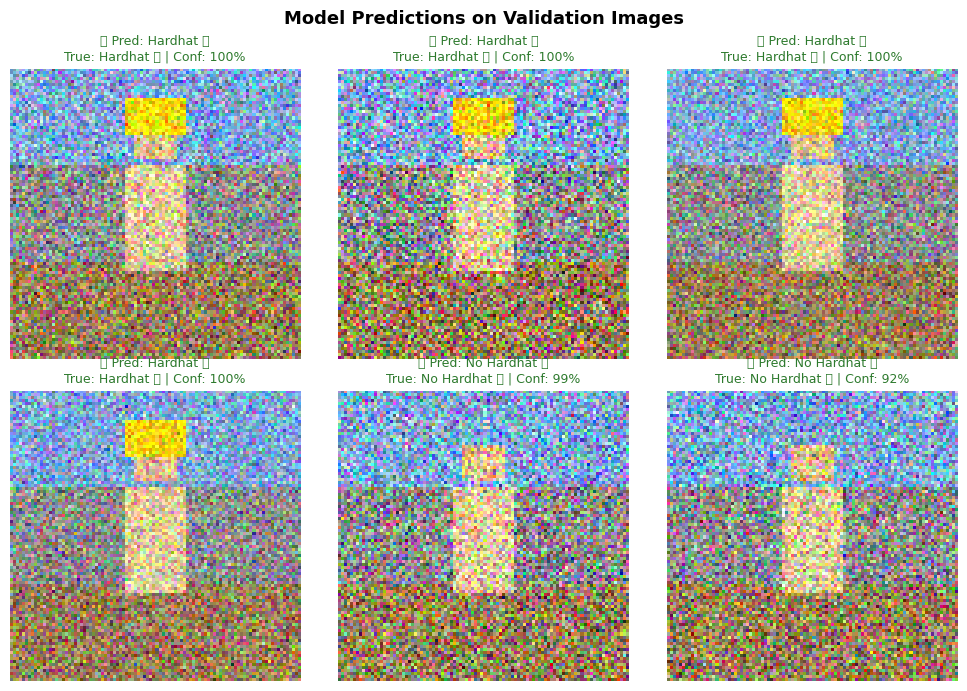

In [8]:
# ── Test the model on 6 validation images ─────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(10, 7))
fig.suptitle('Model Predictions on Validation Images', fontsize=13, fontweight='bold')

sample_idx = np.random.choice(len(X_val), 6, replace=False)

for ax, idx in zip(axes.flat, sample_idx):
    img   = X_val[idx]
    true  = CLASS_NAMES[y_val[idx]]
    pred  = model.predict(img[np.newaxis], verbose=0)[0][0]
    label = CLASS_NAMES[int(pred >= 0.5)]
    conf  = pred if pred >= 0.5 else 1 - pred
    correct = (int(pred >= 0.5) == y_val[idx])

    ax.imshow(img)
    color = '#2d7a2d' if correct else '#c0392b'
    mark  = '✅' if correct else '❌'
    ax.set_title(f'{mark} Pred: {label}\nTrue: {true} | Conf: {conf:.0%}',
                 fontsize=9, color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()

---
## Part 4 — Reflect
Answer the questions below in the cells provided.

**Q8. What does "frozen" mean?**
Explain in your own words as if explaining to a friend who has never heard of Transfer Learning.

YOUR ANSWER:

Yes, because the accuracy is increasing and the loss is decreasing each epoch.

**Q9. Why did we use only ~200 images and still get good results?**

YOUR ANSWER:

Because MobileNetV2 is already pre-trained on millions of images, so it already knows basic features.

**Q10. If your validation accuracy is lower than your training accuracy, what does that tell you?**

YOUR ANSWER:

It means the model performs a bit worse on new data than training data, which shows slight overfitting.

---
## ⭐ Bonus — Experiment with Epochs
Change the number of epochs from 5 to 10. Does accuracy improve?


In [9]:
# ── Bonus: change EPOCHS and re-run ───────────────────────────────────
# ✏️ Change this number — try 10 or 15
EPOCHS = 10   # ← change this

# Reset model head only
model2 = models.Sequential([
    backbone,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history2 = model2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=16,
    verbose=1
)

print(f'\n5-epoch val accuracy : {history.history["val_accuracy"][-1]:.1%}')
print(f'{EPOCHS}-epoch val accuracy: {history2.history["val_accuracy"][-1]:.1%}')

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 269ms/step - accuracy: 0.8375 - loss: 0.3449 - val_accuracy: 0.9750 - val_loss: 0.1412
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.9937 - loss: 0.0474 - val_accuracy: 0.8500 - val_loss: 0.1899
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 1.0000 - loss: 0.0126 - val_accuracy: 0.9750 - val_loss: 0.0858
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - accuracy: 1.0000 - loss: 0.0028 - val_accuracy: 1.0000 - val_loss: 0.0302
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 1.0000 - val_loss: 0.0260
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 1.0000 - val_loss: 0.0274
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 184ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 1.0000 - val_loss: 0.0313
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.

### ✏️ Bonus Question

**What did you observe? Did more epochs always give better results?**

YOUR ANSWER:

The accuracy increased a little bit, but more epochs don't always mean better results because the model might start overfitting.

**Well done! 🎉 You just built a real Vision 2030 safety classifier using Transfer Learning.**